# 05 – Model 3: Gemini 1.5 Flash LLM Pipeline
Zero-shot and few-shot PII extraction via Gemini API.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.utils.io import load_json
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Prompt preview

In [2]:
from src.models.llm_gemini.prompts import build_prompt

sample_text = (
    'My name is Sarah Connor and you can reach me at sarah.c@example.com '
    'or (555) 867-5309. Visit https://sarah-portfolio.dev for my work.'
)

print('=== ZERO-SHOT PROMPT ===')
print(build_prompt(sample_text, few_shot_k=0)[:800], '...')
print('\n=== FEW-SHOT PROMPT (5 examples) ===')
print(build_prompt(sample_text, few_shot_k=5)[:800], '...')

=== ZERO-SHOT PROMPT ===
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the exact substring as it appears in the input
  "type"  – one of: PERSON, EMAIL, PHONE, ADDRESS, URL, ID, USERNAME
  "start" – character offset of the first character of the span
  "end"   – character offset one past the last character of the span

Entity type guide:
PERSON      – full or partial person name (first name, last name, full name)
EMAIL       – email address
PHONE       – phone or fax number
ADDRESS     – street address, city, state, ZIP / postal code, country
URL         – web URL, domain name, IP address
ID          – government ID, SSN, passport, driver's licence, credit-card number, IBAN
USERNAME    – social-media handle, login name, @mention

If ...

=== FEW-SHOT PROMPT (5 examples) ===
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the

## 2. Load pre-computed results (500 records, evaluated on BGU cluster)

In [3]:
# Results pre-computed on BGU cluster (~18 min for 500 records)
results_path = Path('../outputs/results/llm_results.json')
results = load_json(results_path)
m = results['metrics']
print(f"Model: {results['model']}  few_shot_k={results['few_shot_k']}")
print(f"Records evaluated: {m.get('records_evaluated', '?')}")
print(f"Precision: {m['precision']:.4f}  Recall: {m['recall']:.4f}  F1: {m['f1']:.4f}")
print(f"Latency: {m.get('latency_ms_per_record', '?'):.1f} ms / record")

Model: gemini-2.5-flash  few_shot_k=5
Records evaluated: 500
Precision: 0.2063  Recall: 0.1541  F1: 0.1764
Latency: 2195.8 ms / record


## 3. Per-entity F1

,entity,precision,recall,f1,support
3,PERSON,0.2317,0.2074,0.2189,487
1,EMAIL,0.1918,0.1429,0.1637,98
6,USERNAME,0.2000,0.0870,0.1212,23
2,ID,0.1111,0.0769,0.0909,13
0,ADDRESS,0.1228,0.0470,0.0680,149
4,PHONE,0.0000,0.0000,0.0000,16
5,URL,0.0000,0.0000,0.0000,25


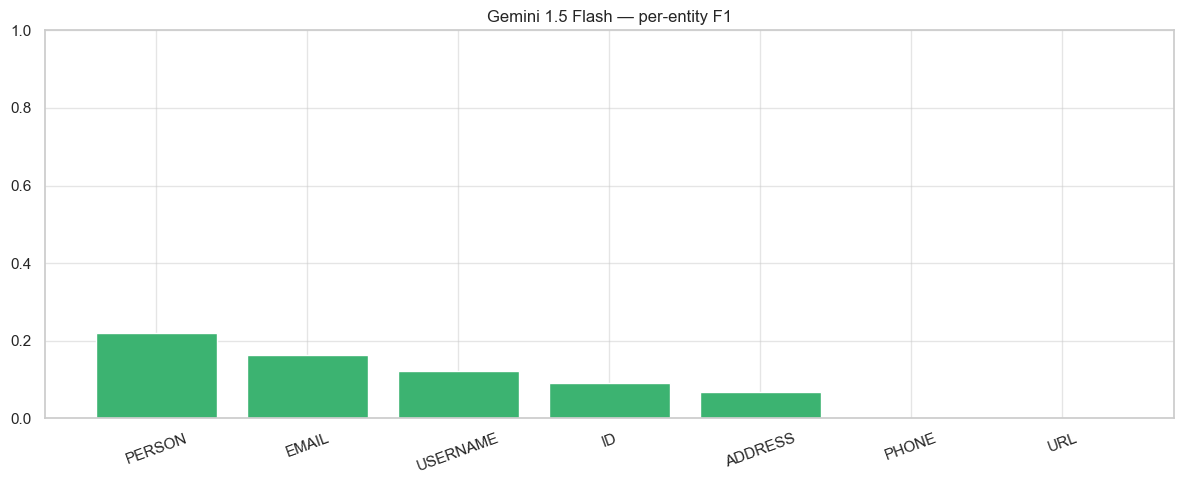

In [4]:
import pandas as pd
per = results['metrics'].get('per_entity', {})
df  = pd.DataFrame([{'entity': k, **v} for k, v in per.items()]).sort_values('f1', ascending=False)
display(df)

fig, ax = plt.subplots()
ax.bar(df['entity'], df['f1'], color='mediumseagreen', edgecolor='white')
ax.set_title('Gemini 1.5 Flash — per-entity F1')
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/results/llm_per_entity_f1.png', dpi=150)
plt.show()

## 4. How the Gemini pipeline works — code walkthrough

In [5]:
from src.models.llm_gemini.prompts import build_prompt, SYSTEM_INSTRUCTION
from src.models.llm_gemini.predictor import _extract_json

# Show the system instruction
print("=== SYSTEM INSTRUCTION (first 300 chars) ===")
print(SYSTEM_INSTRUCTION[:300], "...\n")

# Show zero-shot vs few-shot prompt
sample_text = (
    'Please contact John Smith at jsmith@company.org or call (212) 555-0184. '
    'Patient record #A-447821 for Maria Gonzalez.'
)
print("=== ZERO-SHOT PROMPT (first 600 chars) ===")
print(build_prompt(sample_text, few_shot_k=0)[:600], "...\n")

print("=== FEW-SHOT PROMPT (first 600 chars) ===")
print(build_prompt(sample_text, few_shot_k=5)[:600], "...\n")

# Show the JSON extraction logic
print("=== RESPONSE PARSING EXAMPLE ===")
fake_response = '```json\n[{"type": "PERSON", "start": 15, "end": 25, "text": "John Smith"}]\n```'
parsed = _extract_json(fake_response)
print(f"Raw response: {fake_response}")
print(f"Parsed spans: {parsed}")

=== SYSTEM INSTRUCTION (first 300 chars) ===
You are a precise PII extraction engine. Return ONLY a valid JSON array — no prose, no markdown fences. ...

=== ZERO-SHOT PROMPT (first 600 chars) ===
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the exact substring as it appears in the input
  "type"  – one of: PERSON, EMAIL, PHONE, ADDRESS, URL, ID, USERNAME
  "start" – character offset of the first character of the span
  "end"   – character offset one past the last character of the span

Entity type guide:
PERSON      – full or partial person name (first name, last name, full name)
EMAIL       – email address
PHONE       – phone or fax number
ADDRESS     – street address, city, state, ZIP / postal code, c ...

=== FEW-SHOT PROMPT (first 600 chars) ===
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the exact substring as it 